In [1]:
import sys
import os
sys.path.append(os.path.dirname(os.getcwd()))

In [2]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import root_mean_squared_error
from bart_playground import DefaultBART, ParallelTemperingBART, DataGenerator
import cProfile
import pstats
import io
import time

In [3]:
# PT vs DefaultBART benchmark settings
proposal_probs = {"grow": 0.4, "prune": 0.4, "change": 0.1, "swap": 0.1}
generator = DataGenerator(n_samples=1000, n_features=10, noise=0.1, random_seed=42)
X, y = generator.generate(scenario="heteroscedastic")
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42)

default_kwargs = dict(
    ndpost=7000,
    nskip=3000,
    n_trees=100,
    proposal_probs=proposal_probs,
    random_state=42,
    max_bins=100,
    tol=100,
    quick_decay=False,
    dirichlet_prior=False,
    temperature=1.0,
 )

pt_kwargs = dict(
    ndpost=7000,
    nskip=3000,
    n_trees=100,
    proposal_probs=proposal_probs,
    random_state=42,
    max_bins=100,
    tol=100,
    quick_decay=False,
    dirichlet_prior=False,
    n_temperatures=4,
    max_temperature=3.0,
    swap_interval=5,
    store_chain_traces=False,
 )

In [4]:
# initialize numba (warmup)
warmup_default = DefaultBART(ndpost=5, nskip=5, n_trees=20, proposal_probs=proposal_probs, random_state=7)
_ = warmup_default.fit(X_train[:800], y_train[:800], quietly=True)

warmup_pt = ParallelTemperingBART(
    ndpost=5, nskip=5, n_trees=20, proposal_probs=proposal_probs,
    random_state=7, n_temperatures=3, max_temperature=3.0, swap_interval=2
 )
_ = warmup_pt.fit(X_train[:800], y_train[:800], quietly=True)

print("Numba warmup completed.")

Numba warmup completed.


In [5]:
# helper: format cProfile output
def profile_summary(profiler, top_n=20, sort_key="cumtime"):
    s = io.StringIO()
    pstats.Stats(profiler, stream=s).sort_stats(sort_key).print_stats(top_n)
    return s.getvalue()

# helper: compare RMSE across trained models
def compare_rmse(models, X, y):
    import pandas as pd
    rows = []
    for name, model in models.items():
        rmse = root_mean_squared_error(y, model.predict(X))
        rows.append({"model": name, "rmse": rmse})
    return pd.DataFrame(rows).sort_values("rmse", ascending=True).reset_index(drop=True)

# --- DefaultBART fit + profile ---
default_model = DefaultBART(**default_kwargs)
default_profiler = cProfile.Profile()
t0 = time.perf_counter()
default_profiler.enable()
default_model.fit(X_train, y_train)
default_profiler.disable()
default_fit_seconds = time.perf_counter() - t0
default_profile_text = profile_summary(default_profiler, top_n=20)

# --- ParallelTemperingBART fit + profile ---
pt_model = ParallelTemperingBART(**pt_kwargs)
pt_profiler = cProfile.Profile()
t0 = time.perf_counter()
pt_profiler.enable()
pt_model.fit(X_train, y_train)
pt_profiler.disable()
pt_fit_seconds = time.perf_counter() - t0
pt_profile_text = profile_summary(pt_profiler, top_n=20)

# RMSE comparison via function
rmse_df = compare_rmse(
    {
        "DefaultBART": default_model,
        "ParallelTemperingBART": pt_model,
    },
    X_test,
    y_test,
)

# speed + rmse summary
import pandas as pd
fit_df = pd.DataFrame({
    "model": ["DefaultBART", "ParallelTemperingBART"],
    "fit_seconds": [default_fit_seconds, pt_fit_seconds],
})
fit_df["speedup_vs_default"] = fit_df.loc[0, "fit_seconds"] / fit_df["fit_seconds"]

summary_df = fit_df.merge(rmse_df, on="model", how="left")
print(summary_df)

Iterations: 100%|██████████| 10000/10000 [13:23<00:00, 12.45it/s]


                   model  fit_seconds  speedup_vs_default      rmse
0            DefaultBART   195.646711            1.000000  1.876349
1  ParallelTemperingBART   803.555618            0.243476  1.840515


In [6]:
print("\n=== Top-20 cProfile (DefaultBART) ===")
print(default_profile_text)
print("\n=== Top-20 cProfile (ParallelTemperingBART) ===")
print(pt_profile_text)

pt_params = pt_model.get_params()
print("\nPT temperatures:")
for i, t in enumerate(pt_params.get("temperatures", [])):
    print(f"chain {i}: T={t:.6g}")

print("\nPT swap stats:")
print(pt_params.get("swap_attempts"), pt_params.get("swap_accept_rates"))


=== Top-20 cProfile (DefaultBART) ===
         80877411 function calls (80877379 primitive calls) in 195.647 seconds

   Ordered by: cumulative time
   List reduced from 540 to 20 due to restriction <20>

   ncalls  tottime  percall  cumtime  percall filename:lineno(function)
        2    0.000    0.000  195.646   97.823 c:\Users\ztykk\Phd\BART\bart-playground\.venv\lib\site-packages\IPython\core\interactiveshell.py:3543(run_code)
        2    0.000    0.000  195.646   97.823 {built-in method builtins.exec}
        1    0.000    0.000  195.646  195.646 C:\Users\ztykk\Phd\BART\bart-playground\bart_playground\bart.py:35(fit)
        1    0.000    0.000  195.643  195.643 C:\Users\ztykk\Phd\BART\bart-playground\bart_playground\bart.py:42(fit_with_data)
        1    0.910    0.910  195.643  195.643 C:\Users\ztykk\Phd\BART\bart-playground\bart_playground\samplers.py:93(run)
    10000   15.425    0.002  186.558    0.019 C:\Users\ztykk\Phd\BART\bart-playground\bart_playground\samplers.py:361(

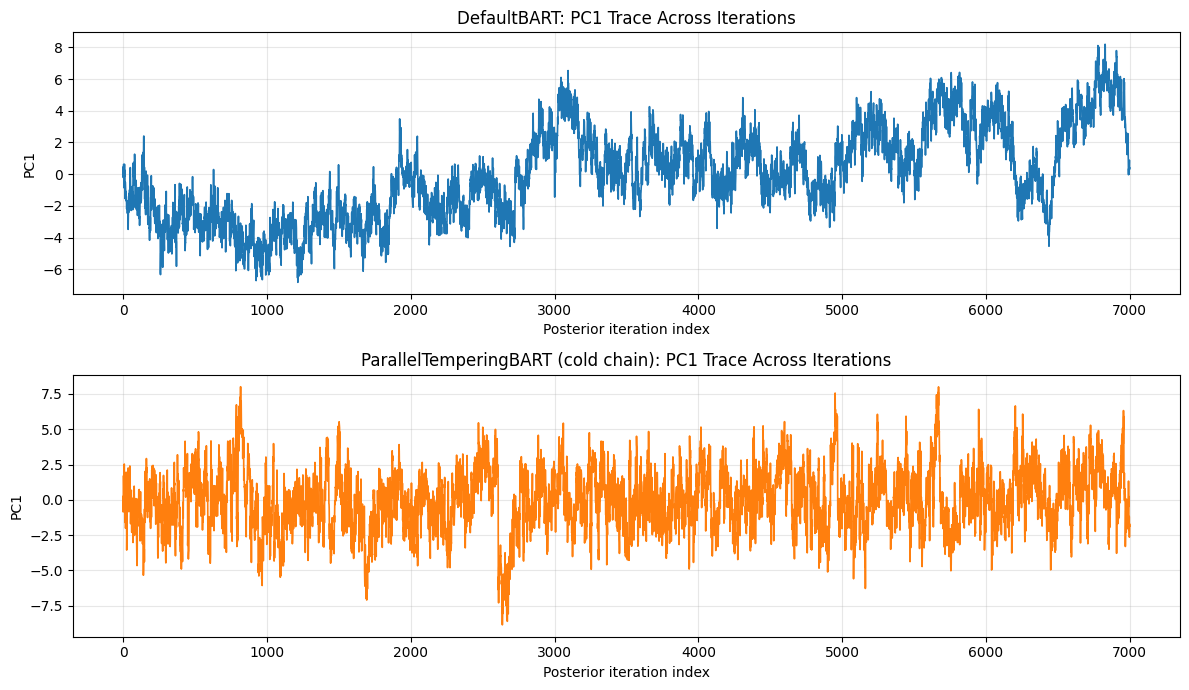

default_pred_mat shape: (7000, 250)
pt_pred_mat shape: (7000, 250)


In [7]:
# Per-iteration prediction traces -> PCA(1D) -> trace plot
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

def posterior_pred_matrix(model, X):
    # Shape: (n_iterations, n_samples)
    mat = np.stack([model.predict_trace(k, X) for k in model.range_post], axis=0)
    return mat

default_pred_mat = posterior_pred_matrix(default_model, X_test)
pt_pred_mat = posterior_pred_matrix(pt_model, X_test)

default_pc1 = PCA(n_components=1).fit_transform(default_pred_mat).ravel()
pt_pc1 = PCA(n_components=1).fit_transform(pt_pred_mat).ravel()

fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=False)
axes[0].plot(default_pc1, lw=1.2)
axes[0].set_title("DefaultBART: PC1 Trace Across Iterations")
axes[0].set_xlabel("Posterior iteration index")
axes[0].set_ylabel("PC1")
axes[0].grid(alpha=0.3)

axes[1].plot(pt_pc1, lw=1.2, color="tab:orange")
axes[1].set_title("ParallelTemperingBART (cold chain): PC1 Trace Across Iterations")
axes[1].set_xlabel("Posterior iteration index")
axes[1].set_ylabel("PC1")
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

print("default_pred_mat shape:", default_pred_mat.shape)
print("pt_pred_mat shape:", pt_pred_mat.shape)